<a href="https://colab.research.google.com/github/CristopherWallau/PythonDataScience/blob/main/Projeto_Evcomx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pré-processamento**


### **Importação**

In [908]:
import pandas as pd

In [909]:
df = pd.read_csv('dados_fundo_do_amanha_evcomx.csv', sep=';')

In [910]:
pd.set_option('display.max_columns', 22)
df.head(n=10)

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
1,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1652,1672,1543.0,1555.0
2,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1650,1670,1543.0,1555.0
3,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1655,1672,1543.0,1555.0
4,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
5,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1651,1672,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
7,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1681,1678,1543.0,1547.0
8,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1680,1678,1543.0,1547.0
9,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1677,1678,1543.0,1547.0


### **Tamanho**

In [911]:
df.shape

(48658, 22)

### **Tipo**

In [912]:
df.dtypes

corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
velocidadeobjetivada     float64
velocidadereal           float64
sugestaomodelolegado       int64
temperaturasaidafp         int64
temperaturaobjetivada    float64
temperaturamediareal     float64
dtype: object

### **Percentual de dados faltantes por coluna**



In [913]:
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().sum() / len(df['corrida'])) * 100
print(faltantes_percentual)

corrida                  0.000000
secao                    0.000000
acoatual                 0.000000
qualidade                0.000000
al_min                   0.000000
c_min                    0.000000
c_max                    0.000000
n_min                    0.000000
s_min                    0.000000
sequencia                0.000000
sequenciatotal           0.000000
panela                   0.000000
vidapanela               0.000000
tempociclo               0.000000
tempovacuototal          0.000000
temperaturaliquidus      0.000000
velocidadeobjetivada     0.000000
velocidadereal           0.000000
sugestaomodelolegado     0.000000
temperaturasaidafp       0.000000
temperaturaobjetivada    0.000000
temperaturamediareal     0.024662
dtype: float64


In [ ]:
# Como a porcentagem de dados faltantes é irrelevante(menos de 5%) apenas descartamos os valores NAN e/ou nulos

df = df.dropna()

### **Removendo colunas duplicadas**

In [ ]:
# Removemos as colunas duplicadas baseado na coluna corrida e mantendo a mais recente conforme instruido

df = df.drop_duplicates(subset=['corrida'], keep='first')
df.shape

(7482, 22)

In [ ]:
# Remoção da variável “corrida”, pois só servia para conferir valores duplicados, é irrelevante para a análise

df = df.drop('corrida', axis=1)

# **Análise exploratória**

In [917]:
import matplotlib.pyplot as plt
import seaborn as sns
from optbinning import ContinuousOptimalBinning

In [918]:
df.head()

,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


In [919]:
valores_unicos = df.nunique()

print(valores_unicos)

secao                       2
acoatual                 3503
qualidade                 253
al_min                      4
c_min                     121
c_max                     126
n_min                       3
s_min                      29
sequencia                  11
sequenciatotal             11
panela                     12
vidapanela                 76
tempociclo               3902
tempovacuototal            24
temperaturaliquidus        49
velocidadeobjetivada       13
velocidadereal            115
sugestaomodelolegado      134
temperaturasaidafp        138
temperaturaobjetivada      59
temperaturamediareal      105
dtype: int64


In [920]:
# a quantidade de valores únicos de acoatual corresponde a aproximadamente metade do total
# a coluna acoatual foi removida e apenas qualidade será usada para diferenciar os aços

# df = df.drop('acoatual', axis=1)

### **Comportamento target (temperaturasaidafp)**

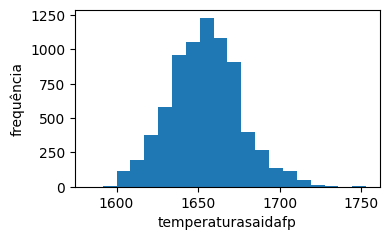

In [921]:
plt.figure(figsize=(4,2.5))

plt.hist(df['temperaturasaidafp'], bins=20)
plt.xlabel('temperaturasaidafp')
plt.ylabel('frequência')
plt.tight_layout()
plt.show()

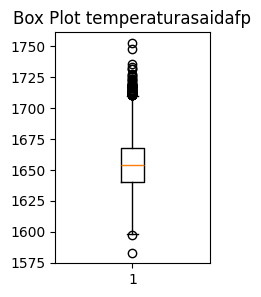

In [922]:
plt.figure(figsize=(2, 3))

plt.boxplot(df.temperaturasaidafp)
plt.title("Box Plot temperaturasaidafp")
plt.show()

In [923]:
media = df['temperaturasaidafp'].mean()
mediana = df['temperaturasaidafp'].median()

print(f"Média: {media}")
print(f"Mediana: {mediana}")

Média: 1653.9966586474204
Mediana: 1654.0


In [924]:
df['temperaturasaidafp'].describe()

count    7482.000000
mean     1653.996659
std        21.710404
min      1583.000000
25%      1640.000000
50%      1654.000000
75%      1668.000000
max      1753.000000
Name: temperaturasaidafp, dtype: float64

### **Comportamento target x acoatual**

In [925]:
n_categorias = df['acoatual'].nunique()

optb = ContinuousOptimalBinning(
    name='acoatual',
    dtype='categorical',
    max_n_prebins=n_categorias,
    min_prebin_size=0.025
)

optb.fit(df['acoatual'], df['temperaturasaidafp'])

,name,'acoatual'
,dtype,'categorical'
,prebinning_method,'cart'
,max_n_prebins,3503
,min_prebin_size,0.025
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,monotonic_trend,'auto'
,min_mean_diff,0


In [926]:
binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"[6CC5E01C, 2CDDC4D0, 1FABAD71, 2A3CF6E8, 4866B...",226,0.030206,365483.0,9.972431,1617.181416,1583.0,1650.0,0,-36.815243,1.112035
1,"[71E889B5, 45187F18, A91F15D7, 5715B98E, B45B8...",313,0.041834,510172.0,13.280816,1629.942492,1602.0,1680.0,0,-24.054167,1.006276
2,"[8380F089, 4BAC542C, 4DA60812, FEAECDC7, 7D9C4...",234,0.031275,382561.0,14.905315,1634.876068,1602.0,1678.0,0,-19.120590,0.597998
3,"[19D8C68E, 5C4D51A8, D14EF008, 5DD8591E, DD661...",263,0.035151,430793.0,15.63765,1637.996198,1600.0,1699.0,0,-16.000461,0.562433
4,"[64071221, FFE5B3F8, F6949EAE, B0F306DD, 08B59...",286,0.038225,469201.0,15.936979,1640.562937,1601.0,1695.0,0,-13.433722,0.513505
5,"[88BBA8F1, 96EC8D8F, 003E2C21, 367B3398, DDCEB...",188,0.025127,308735.0,16.309329,1642.207447,1603.0,1688.0,0,-11.789212,0.296227
6,"[D221FEDC, B21E82C2, D21F4448, 84C28B86, 4875A...",269,0.035953,442097.0,14.90904,1643.483271,1607.0,1696.0,0,-10.513387,0.377987
7,"[A5FE3E56, 0EC30B33, 1023513B, 5A7A1D86, 32E9F...",361,0.048249,593934.0,15.038,1645.246537,1598.0,1685.0,0,-8.750121,0.422186
8,"[7030F7CA, 69E650A6, 0DE0FD16, CA1A71A8, C203B...",203,0.027132,334291.0,15.555349,1646.753695,1609.0,1715.0,0,-7.242964,0.196515
9,"[1A9C944B, F903584B, 99F31DCF, 56DF0A38, C3314...",188,0.025127,309762.0,15.667006,1647.670213,1605.0,1698.0,0,-6.326446,0.158964


In [927]:
tabela = binning_table[0] if isinstance(binning_table, tuple) else binning_table

mapa_cat_woe = {}

for _, row in tabela.iterrows():
    categorias = row['Bin']           # já é lista/array, não precisa de ast.literal_eval
    woe = row['WoE']
    for cat in categorias:
        mapa_cat_woe[cat] = woe

In [928]:
df['acoatual_woe'] = df['acoatual'].map(mapa_cat_woe)
df = df.drop(columns=['acoatual'])
df.head()

,secao,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,acoatual_woe
0,180.0,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,2.220915
6,180.0,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,9.449622
28,90.0,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,17.706312
36,90.0,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,9.449622
40,90.0,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,28.272873


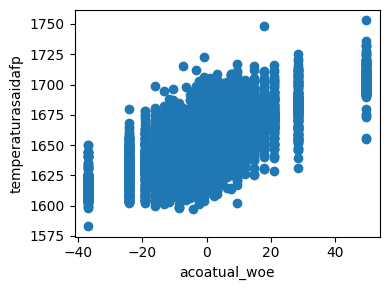

In [929]:
plt.figure(figsize=(4, 3))

plt.scatter(df['acoatual_woe'], df['temperaturasaidafp'])
plt.xlabel('acoatual_woe')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

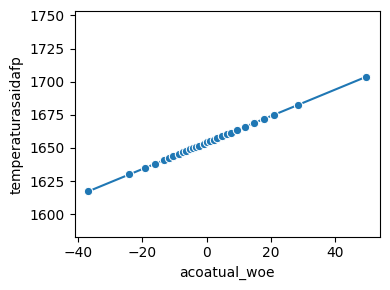

In [930]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='acoatual_woe', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('acoatual_woe')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x qualidade**

In [931]:
n_categorias = df['qualidade'].nunique()

optb = ContinuousOptimalBinning(
    name='qualidade',
    dtype='categorical',
    max_n_prebins=n_categorias,
    min_prebin_size=0.02
)

optb.fit(df['qualidade'], df['temperaturasaidafp'])

,name,'qualidade'
,dtype,'categorical'
,prebinning_method,'cart'
,max_n_prebins,253
,min_prebin_size,0.02
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,monotonic_trend,'auto'
,min_mean_diff,0


In [932]:
binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"[D6090DB2, EE94AA85, 0731C1FB, 4D302CE7, E154D...",341,0.045576,550516.0,10.58368,1614.416422,1583.0,1655.0,0,-39.580236,1.803911
1,"[22ADB3F3, 76884E9D, FC8C358D, 12A9E163, 93C0A...",390,0.052125,634705.0,12.747496,1627.448718,1603.0,1679.0,0,-26.547941,1.383814
2,"[502F0F5B, 246988A2, 2559381B, B4CD6E45, E9D2B...",253,0.033814,413146.0,11.635601,1632.988142,1607.0,1675.0,0,-21.008516,0.710392
3,"[9970B431, 332091CC, B5D5B9CA]",269,0.035953,439840.0,13.335069,1635.092937,1610.0,1688.0,0,-18.903722,0.679645
4,"[D115251A, DD4524C7, 0B13406F, 1EF55151, 92E96...",413,0.055199,676850.0,12.188505,1638.861985,1615.0,1684.0,0,-15.134673,0.835421
5,"[B87AB689, 5E203A14, 46F56B8C, 3BA0D398]",325,0.043438,533624.0,13.819041,1641.920000,1615.0,1700.0,0,-12.076659,0.524581
6,"[493EAF60, 53C00FD5, 25016671, E294A4B5, 2E698...",178,0.023790,292372.0,11.146175,1642.539326,1621.0,1691.0,0,-11.457333,0.272575
7,"[7AFEE53C, 5A195F30, F7838086, E355BC35, D6BA9...",165,0.022053,271253.0,14.21751,1643.957576,1605.0,1710.0,0,-10.039083,0.221391
8,"[9C0993CD, 6570BD8E, 7F441B8F, BB15B95F, B1EBA...",167,0.022320,274666.0,11.336081,1644.706587,1621.0,1698.0,0,-9.290072,0.207357
9,"[E25D9AF5, 61541AEF, 1137DC9F, 8F93E3D1, 8288B...",282,0.037690,464551.0,9.221013,1647.343972,1630.0,1689.0,0,-6.652687,0.250743


In [933]:
tabela = binning_table[0] if isinstance(binning_table, tuple) else binning_table

mapa_cat_woe = {}

for _, row in tabela.iterrows():
    categorias = row['Bin']           # já é lista/array, não precisa de ast.literal_eval
    woe = row['WoE']
    for cat in categorias:
        mapa_cat_woe[cat] = woe

In [934]:
df['qualidade_woe'] = df['qualidade'].map(mapa_cat_woe)
df = df.drop(columns=['qualidade'])
df.head()

,secao,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,acoatual_woe,qualidade_woe
0,180.0,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,2.220915,20.758392
6,180.0,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,9.449622,20.758392
28,90.0,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,17.706312,7.625461
36,90.0,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,9.449622,7.625461
40,90.0,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,28.272873,7.625461


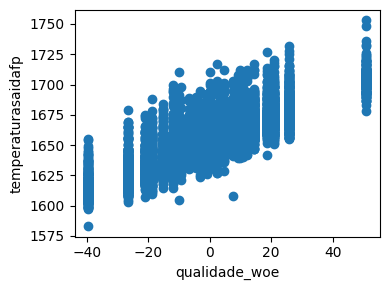

In [935]:
plt.figure(figsize=(4, 3))

plt.scatter(df['qualidade_woe'], df['temperaturasaidafp'])
plt.xlabel('qualidade_woe')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

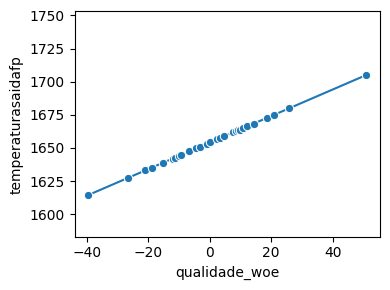

In [936]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='qualidade_woe', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('qualidade_woe')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x secao**

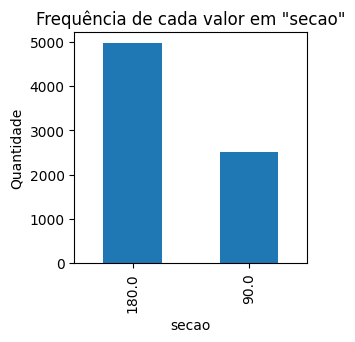

In [937]:
import pandas as pd
import matplotlib.pyplot as plt

contagem = df['secao'].value_counts()

plt.figure(figsize=(3,3))
contagem.plot(kind='bar')

plt.title('Frequência de cada valor em "secao"')
plt.ylabel('Quantidade')

plt.show()

In [938]:
df.groupby('secao')['temperaturasaidafp'].describe()

,count,mean,std,min,25%,50%,75%,max
secao,,,,,,,,
90.0,2511.0,1650.855834,18.538641,1603.0,1639.0,1650.0,1662.0,1725.0
180.0,4971.0,1655.583182,22.987112,1583.0,1640.0,1656.0,1670.0,1753.0


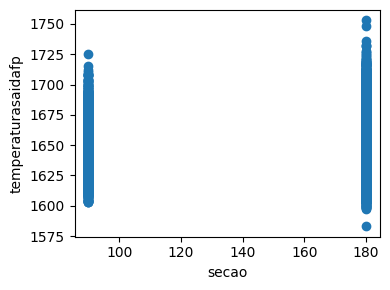

In [939]:
plt.figure(figsize=(4, 3))

plt.scatter(df['secao'], df['temperaturasaidafp'])
plt.xlabel('secao')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

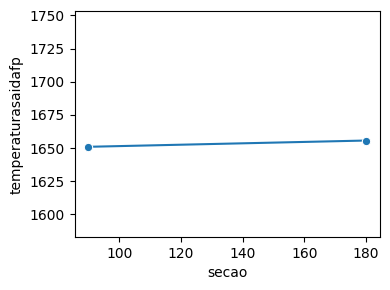

In [940]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='secao', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('secao')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x al_min**

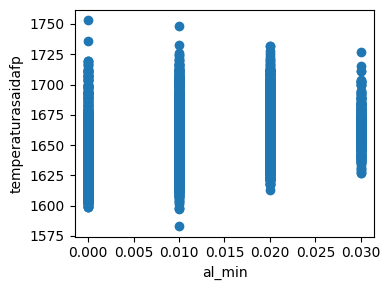

In [941]:
plt.figure(figsize=(4, 3))

plt.scatter(df['al_min'], df['temperaturasaidafp'])
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

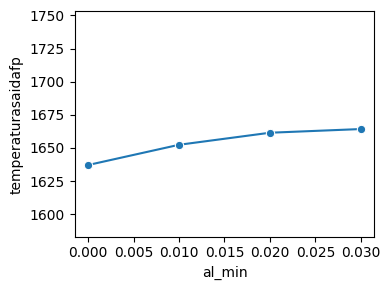

In [942]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='al_min', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x c_min**

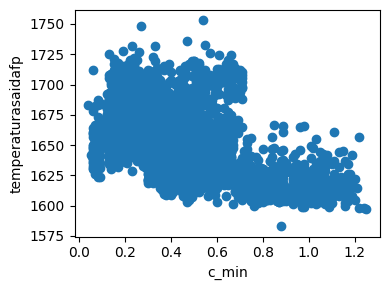

In [943]:
plt.figure(figsize=(4, 3))

plt.scatter(df['c_min'], df['temperaturasaidafp'])
plt.xlabel('c_min')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

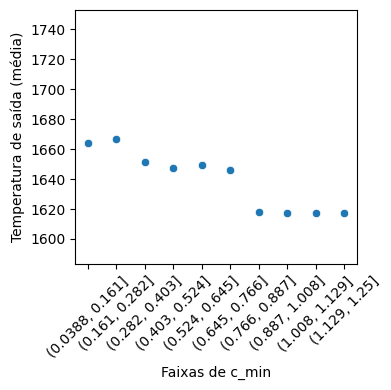

In [944]:
df['c_min_grupo'] = pd.cut(df['c_min'], bins=10)

media = df.groupby('c_min_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['c_min_grupo'] = media['c_min_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='c_min_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de c_min')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [945]:
df = df.drop(columns=['c_min_grupo'])

### **Comportamento target x c_max**

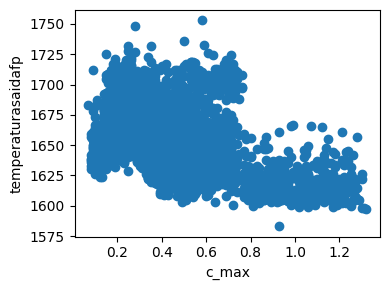

In [946]:
plt.figure(figsize=(4, 3))

plt.scatter(df['c_max'], df['temperaturasaidafp'])
plt.xlabel('c_max')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

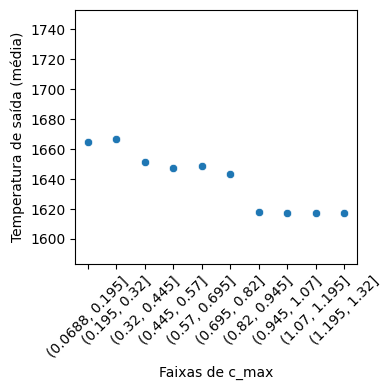

In [947]:
df['c_max_grupo'] = pd.cut(df['c_max'], bins=10)

media = df.groupby('c_max_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['c_max_grupo'] = media['c_max_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='c_max_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de c_max')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [948]:
df = df.drop(columns=['c_max_grupo'])

### **Comportamento target x n_min**

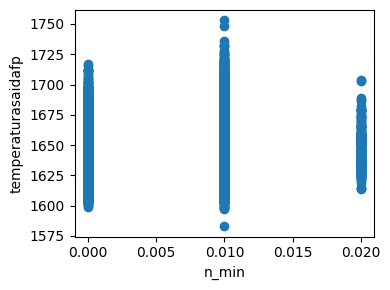

In [949]:
plt.figure(figsize=(4, 3))

plt.scatter(df['n_min'], df['temperaturasaidafp'])
plt.xlabel('n_min')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

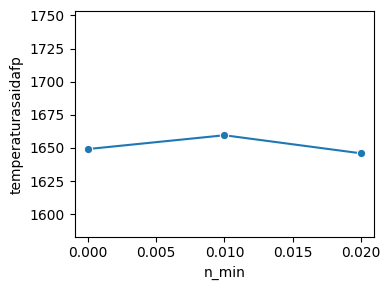

In [950]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='n_min', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('n_min')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x s_min**

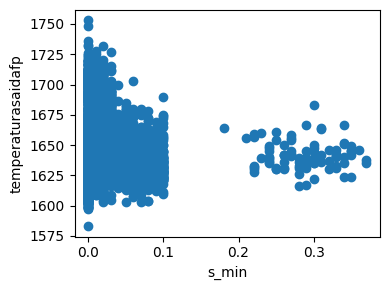

In [951]:
plt.figure(figsize=(4, 3))
plt.scatter(df['s_min'], df['temperaturasaidafp'])
plt.xlabel('s_min')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

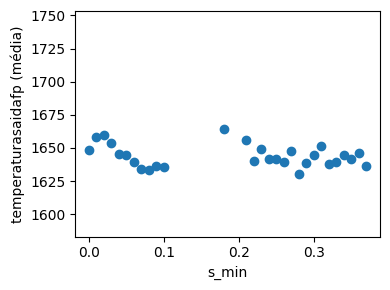

In [952]:
df_mean = df.groupby('s_min', as_index=False)['temperaturasaidafp'].mean()

plt.figure(figsize=(4, 3))
plt.scatter(df_mean['s_min'], df_mean['temperaturasaidafp'], marker='o')
plt.xlabel('s_min')
plt.ylabel('temperaturasaidafp (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x sequencia**

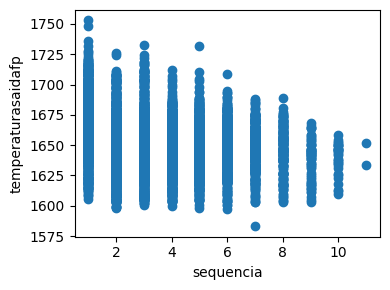

In [953]:
plt.figure(figsize=(4, 3))
plt.scatter(df['sequencia'], df['temperaturasaidafp'])
plt.xlabel('sequencia')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

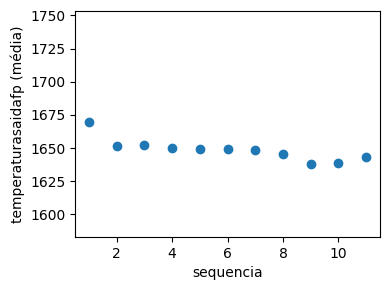

In [954]:
df_mean = df.groupby('sequencia', as_index=False)['temperaturasaidafp'].mean()

plt.figure(figsize=(4, 3))
plt.scatter(df_mean['sequencia'], df_mean['temperaturasaidafp'], marker='o')
plt.xlabel('sequencia')
plt.ylabel('temperaturasaidafp (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x sequanciatotal**

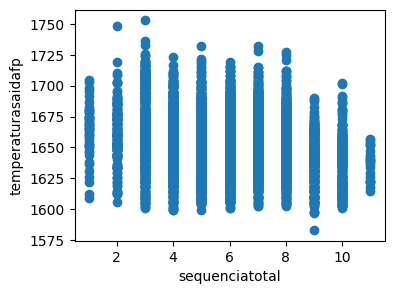

In [955]:
plt.figure(figsize=(4, 3))
plt.scatter(df['sequenciatotal'], df['temperaturasaidafp'])
plt.xlabel('sequenciatotal')
plt.ylabel('temperaturasaidafp')
plt.show()

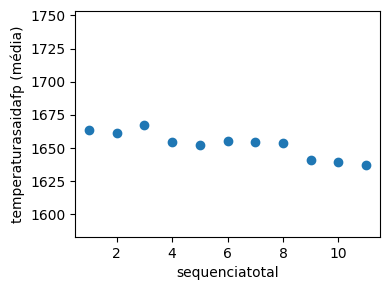

In [956]:
df_mean = df.groupby('sequenciatotal', as_index=False)['temperaturasaidafp'].mean()

plt.figure(figsize=(4, 3))
plt.scatter(df_mean['sequenciatotal'], df_mean['temperaturasaidafp'], marker='o')
plt.xlabel('sequenciatotal')
plt.ylabel('temperaturasaidafp (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x panela**

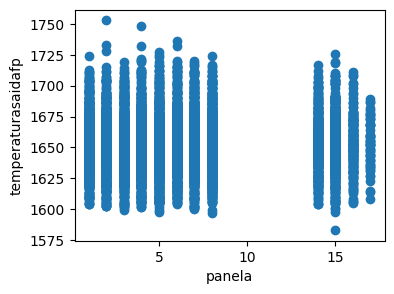

In [957]:
plt.figure(figsize=(4, 3))
plt.scatter(df['panela'], df['temperaturasaidafp'])
plt.xlabel('panela')
plt.ylabel('temperaturasaidafp')
plt.show()

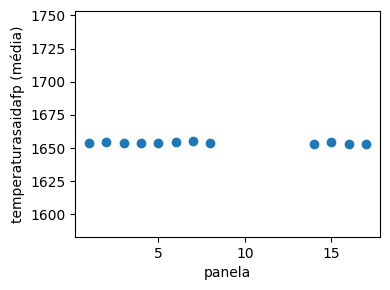

In [958]:
df_mean = df.groupby('panela', as_index=False)['temperaturasaidafp'].mean()

plt.figure(figsize=(4, 3))
plt.scatter(df_mean['panela'], df_mean['temperaturasaidafp'], marker='o')
plt.xlabel('panela')
plt.ylabel('temperaturasaidafp (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

In [959]:
n_categorias = df['panela'].nunique()

optb = ContinuousOptimalBinning(
    name='panela',
    dtype='categorical',
    )

optb.fit(df['panela'], df['temperaturasaidafp'])

,name,'panela'
,dtype,'categorical'
,prebinning_method,'cart'
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,monotonic_trend,'auto'
,min_mean_diff,0


In [960]:
binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"[17.0, 16.0, 14.0]",671,0.089682,1109280.0,20.750401,1653.174367,1604.0,1717.0,0,-0.822292,0.073745
1,[5.0],802,0.107191,1326038.0,22.366215,1653.413965,1598.0,1727.0,0,-0.582694,0.062459
2,[4.0],755,0.100909,1248404.0,22.289028,1653.515232,1602.0,1748.0,0,-0.481427,0.048580
3,[8.0],803,0.107324,1327915.0,21.635524,1653.692403,1597.0,1724.0,0,-0.304255,0.032654
4,[1.0],780,0.104250,1290052.0,20.848971,1653.912821,1604.0,1724.0,0,-0.083838,0.008740
5,[3.0],703,0.093959,1162752.0,21.684006,1653.985775,1599.0,1719.0,0,-0.010883,0.001023
6,[2.0],774,0.103448,1280332.0,21.426339,1654.175711,1603.0,1753.0,0,0.179052,0.018523
7,[15.0],661,0.088345,1093558.0,21.609187,1654.399395,1583.0,1726.0,0,0.402736,0.035580
8,[6.0],809,0.108126,1338432.0,21.978864,1654.427689,1604.0,1736.0,0,0.431030,0.046606
9,[7.0],724,0.096766,1198440.0,22.240808,1655.303867,1600.0,1720.0,0,1.307209,0.126493


In [961]:
tabela = binning_table[0] if isinstance(binning_table, tuple) else binning_table

mapa_cat_woe = {}

for _, row in tabela.iterrows():
    categorias = row['Bin']           # já é lista/array, não precisa de ast.literal_eval
    woe = row['WoE']
    for cat in categorias:
        mapa_cat_woe[cat] = woe

In [962]:
df['panela_woe'] = df['panela'].map(mapa_cat_woe)
df = df.drop(columns=['panela'])
df.head()

,secao,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,acoatual_woe,qualidade_woe,panela_woe
0,180.0,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,2.220915,20.758392,0.402736
6,180.0,0.02,0.14,0.16,0.01,0.01,1.0,2.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,9.449622,20.758392,-0.822292
28,90.0,0.02,0.15,0.17,0.01,0.02,3.0,3.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,17.706312,7.625461,0.431030
36,90.0,0.02,0.17,0.19,0.01,0.02,1.0,3.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,9.449622,7.625461,0.402736
40,90.0,0.02,0.15,0.17,0.01,0.02,1.0,3.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,28.272873,7.625461,-0.083838


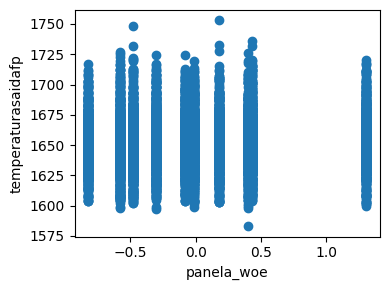

In [963]:
plt.figure(figsize=(4, 3))

plt.scatter(df['panela_woe'], df['temperaturasaidafp'])
plt.xlabel('panela_woe')
plt.ylabel('temperaturasaidafp')
plt.tight_layout()
plt.show()

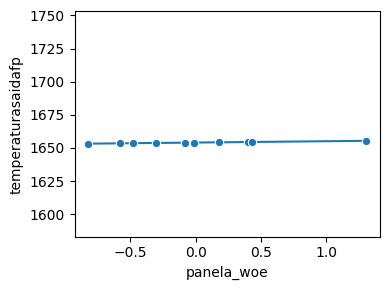

In [964]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='panela_woe', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('panela_woe')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x vidapanela**

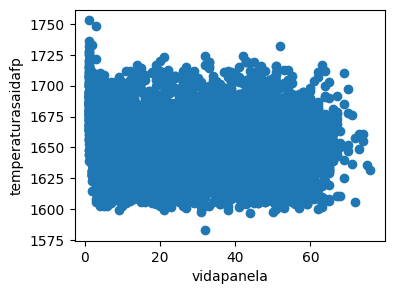

In [965]:
plt.figure(figsize=(4, 3))
plt.scatter(df['vidapanela'], df['temperaturasaidafp'])
plt.xlabel('vidapanela')
plt.ylabel('temperaturasaidafp')
plt.show()

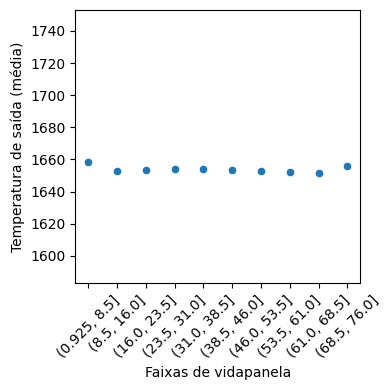

In [966]:
df['vidapanela_grupo'] = pd.cut(df['vidapanela'], bins=10)

media = df.groupby('vidapanela_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['vidapanela_grupo'] = media['vidapanela_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='vidapanela_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de vidapanela')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [967]:
df = df.drop(columns=['vidapanela_grupo'])

### **Comportamento target x tempociclo**

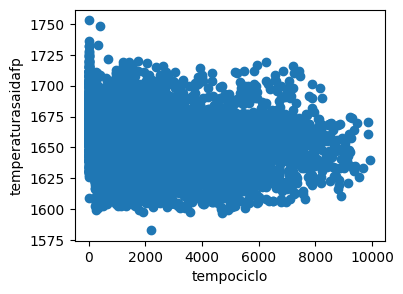

In [968]:
plt.figure(figsize=(4, 3))
plt.scatter(df['tempociclo'], df['temperaturasaidafp'])
plt.xlabel('tempociclo')
plt.ylabel('temperaturasaidafp')
plt.show()

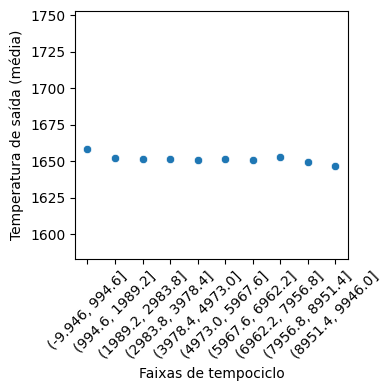

In [969]:
df['tempociclo_grupo'] = pd.cut(df['tempociclo'], bins=10)

media = df.groupby('tempociclo_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['tempociclo_grupo'] = media['tempociclo_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='tempociclo_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de tempociclo')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [970]:
df = df.drop(columns=['tempociclo_grupo'])

### **Comportamento target x tempovacuototal**

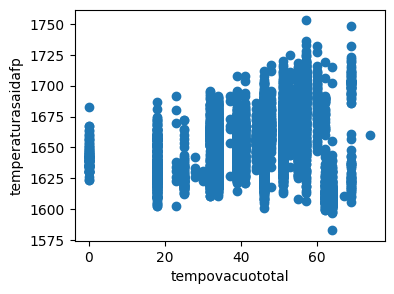

In [971]:
plt.figure(figsize=(4, 3))
plt.scatter(df['tempovacuototal'], df['temperaturasaidafp'])
plt.xlabel('tempovacuototal')
plt.ylabel('temperaturasaidafp')
plt.show()

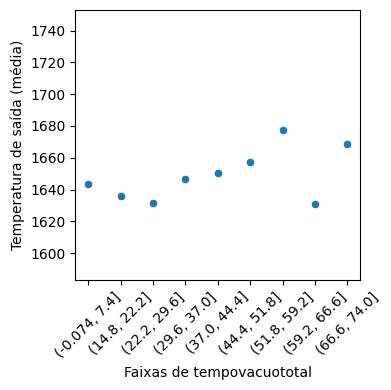

In [972]:
df['tempovacuototal_grupo'] = pd.cut(df['tempovacuototal'], bins=10)

media = df.groupby('tempovacuototal_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['tempovacuototal_grupo'] = media['tempovacuototal_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='tempovacuototal_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de tempovacuototal')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [973]:
df = df.drop(columns=['tempovacuototal_grupo'])

### **Comportamento target x temperaturaliquidus**

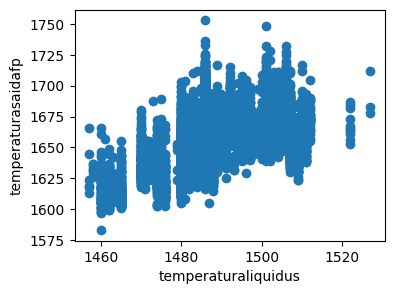

In [974]:
plt.figure(figsize=(4, 3))
plt.scatter(df['temperaturaliquidus'], df['temperaturasaidafp'])
plt.xlabel('temperaturaliquidus')
plt.ylabel('temperaturasaidafp')
plt.show()

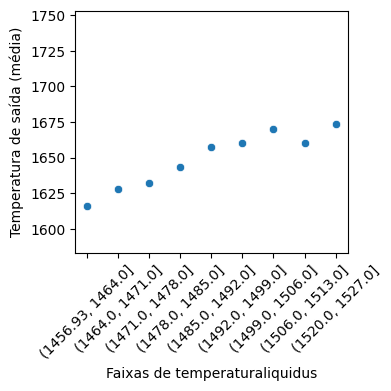

In [975]:
df['temperaturaliquidus_grupo'] = pd.cut(df['temperaturaliquidus'], bins=10)

media = df.groupby('temperaturaliquidus_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['temperaturaliquidus_grupo'] = media['temperaturaliquidus_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='temperaturaliquidus_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de temperaturaliquidus')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [976]:
df = df.drop(columns=['temperaturaliquidus_grupo'])

### **Comportamento target x velocidadeobjetivada**

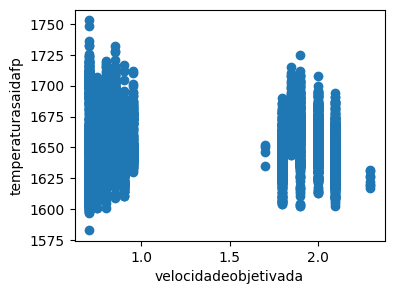

In [977]:
plt.figure(figsize=(4, 3))
plt.scatter(df['velocidadeobjetivada'], df['temperaturasaidafp'])
plt.xlabel('velocidadeobjetivada')
plt.ylabel('temperaturasaidafp')
plt.show()

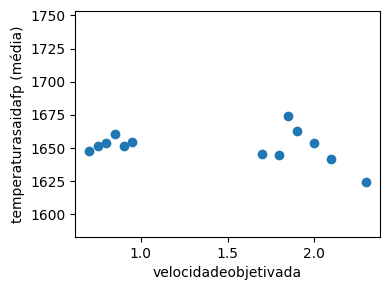

In [978]:
df_mean = df.groupby('velocidadeobjetivada', as_index=False)['temperaturasaidafp'].mean()

plt.figure(figsize=(4, 3))
plt.scatter(df_mean['velocidadeobjetivada'], df_mean['temperaturasaidafp'], marker='o')
plt.xlabel('velocidadeobjetivada')
plt.ylabel('temperaturasaidafp (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.tight_layout()
plt.show()

### **Comportamento target x velocidadereal**

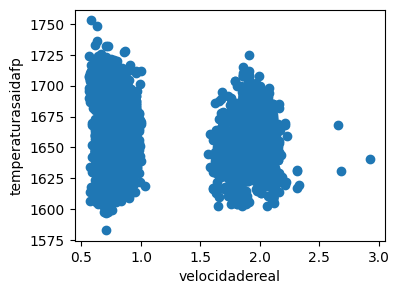

In [979]:
plt.figure(figsize=(4, 3))
plt.scatter(df['velocidadereal'], df['temperaturasaidafp'])
plt.xlabel('velocidadereal')
plt.ylabel('temperaturasaidafp')
plt.show()

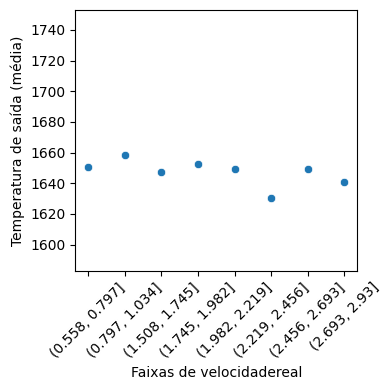

In [980]:
df['velocidadereal_grupo'] = pd.cut(df['velocidadereal'], bins=10)

media = df.groupby('velocidadereal_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['velocidadereal_grupo'] = media['velocidadereal_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='velocidadereal_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de velocidadereal')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [981]:
df = df.drop(columns=['velocidadereal_grupo'])

### **Comportamento target x sugestaomodelolegado**

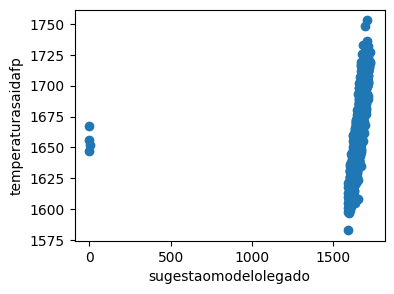

In [982]:
plt.figure(figsize=(4, 3))
plt.scatter(df['sugestaomodelolegado'], df['temperaturasaidafp'])
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturasaidafp')
plt.show()

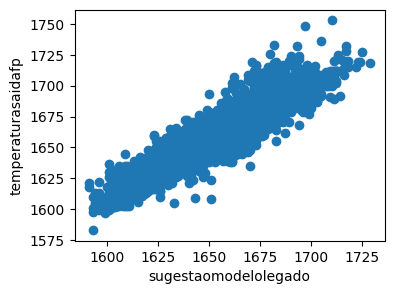

In [983]:
# os valores muito baixos de sugestaomodelolegado são outliers e devem ser removidos
df = df[df['sugestaomodelolegado'] >= 500]

plt.figure(figsize=(4, 3))
plt.scatter(df['sugestaomodelolegado'], df['temperaturasaidafp'])
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturasaidafp')
plt.show()

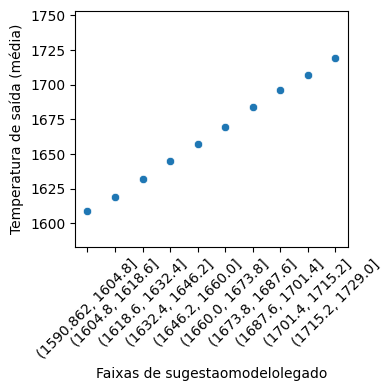

In [984]:
df['sugestaomodelolegado_grupo'] = pd.cut(df['sugestaomodelolegado'], bins=10)

media = df.groupby('sugestaomodelolegado_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['sugestaomodelolegado_grupo'] = media['sugestaomodelolegado_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='sugestaomodelolegado_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de sugestaomodelolegado')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [985]:
df = df.drop(columns=['sugestaomodelolegado_grupo'])

### **Comportamento target x temperaturaobjetivada**

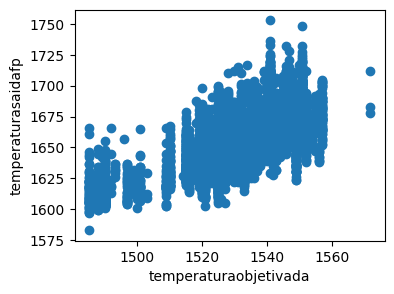

In [986]:
plt.figure(figsize=(4, 3))
plt.scatter(df['temperaturaobjetivada'], df['temperaturasaidafp'])
plt.xlabel('temperaturaobjetivada')
plt.ylabel('temperaturasaidafp')
plt.show()

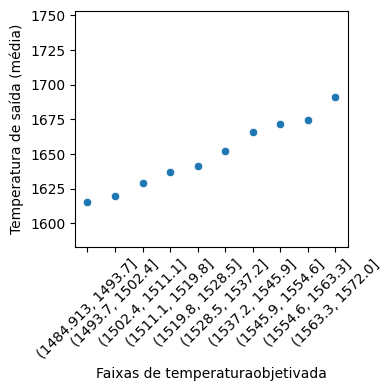

In [987]:
df['temperaturaobjetivada_grupo'] = pd.cut(df['temperaturaobjetivada'], bins=10)

media = df.groupby('temperaturaobjetivada_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['temperaturaobjetivada_grupo'] = media['temperaturaobjetivada_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='temperaturaobjetivada_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de temperaturaobjetivada')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [988]:
df = df.drop(columns=['temperaturaobjetivada_grupo'])

### **Comportamento target x temperaturamediareal**

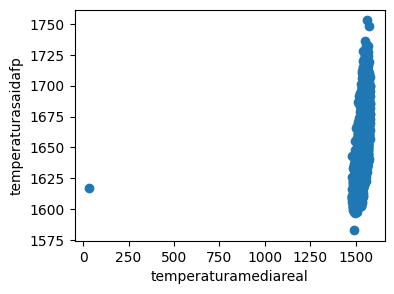

In [989]:
plt.figure(figsize=(4, 3))
plt.scatter(df['temperaturamediareal'], df['temperaturasaidafp'])
plt.xlabel('temperaturamediareal')
plt.ylabel('temperaturasaidafp')
plt.show()

In [990]:
# os valores muito baixos de temperaturamediareal são outliers e devem ser removidos
df = df[df['temperaturamediareal'] >= 500]

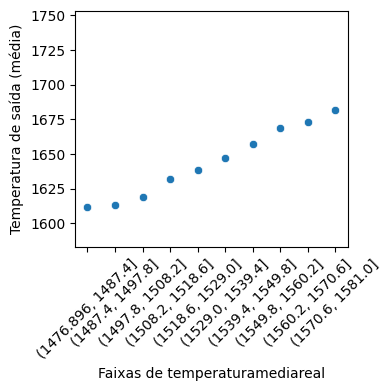

In [991]:
df['temperaturamediareal_grupo'] = pd.cut(df['temperaturamediareal'], bins=10)

media = df.groupby('temperaturamediareal_grupo', observed=True)['temperaturasaidafp'].mean().reset_index()

media['temperaturamediareal_grupo'] = media['temperaturamediareal_grupo'].astype(str)

plt.figure(figsize=(4, 4))

sns.scatterplot(data=media, x='temperaturamediareal_grupo', y='temperaturasaidafp')
plt.xlabel('Faixas de temperaturamediareal')
plt.ylabel('Temperatura de saída (média)')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [992]:
df = df.drop(columns=['temperaturamediareal_grupo'])

# **Seleção de variáveis**

In [993]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [994]:
pd.set_option('display.max_columns', 22)
df.head()

,secao,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,acoatual_woe,qualidade_woe,panela_woe
0,180.0,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,2.220915,20.758392,0.402736
6,180.0,0.02,0.14,0.16,0.01,0.01,1.0,2.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,9.449622,20.758392,-0.822292
28,90.0,0.02,0.15,0.17,0.01,0.02,3.0,3.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,17.706312,7.625461,0.431030
36,90.0,0.02,0.17,0.19,0.01,0.02,1.0,3.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,9.449622,7.625461,0.402736
40,90.0,0.02,0.15,0.17,0.01,0.02,1.0,3.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,28.272873,7.625461,-0.083838


**Correlação**

In [995]:
df_corr = df.drop(columns=['velocidadereal', 'temperaturamediareal'])

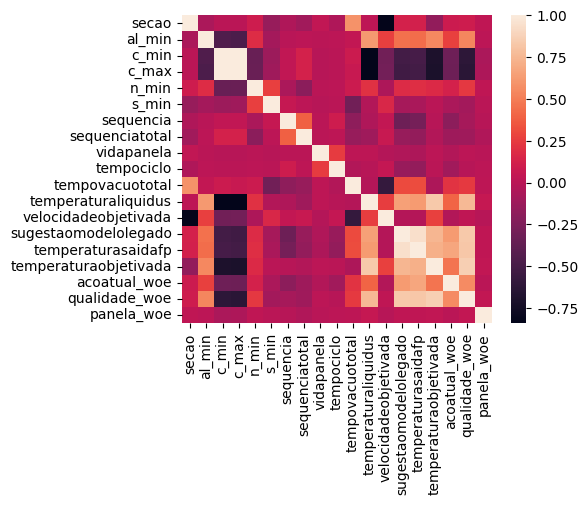

In [996]:
corr = df_corr.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(5, 4))
sns.heatmap(corr)
plt.show()

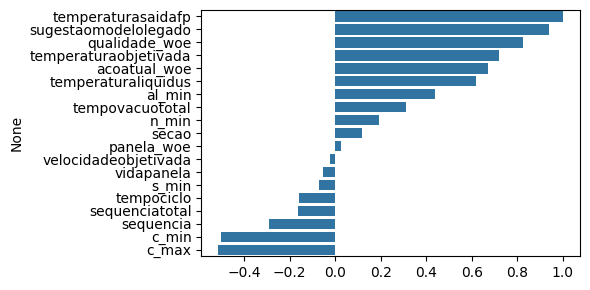

In [997]:
plt.figure(figsize=(6,3))

correlacoes = df_corr.corr(method='spearman', numeric_only=True)['temperaturasaidafp'].sort_values(ascending=False)
sns.barplot(x=correlacoes.values, y=correlacoes.index)
plt.tight_layout()
plt.show()

# Valores próximos de 1 → correlação positiva forte
# Valores próximos de -1 → correlação negativa forte
# Valores próximos de 0 → pouca ou nenhuma correlação linear

**VIF ((Fator de Inflação da Variância)**

In [998]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Select the independent variables
X = df_corr[['secao', 'al_min', 'c_min', 'c_max', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 'velocidadeobjetivada', 'sugestaomodelolegado', 'temperaturaobjetivada', 'acoatual_woe', 'qualidade_woe', 'panela_woe']]

# Add a constant to the independent variables dataframe
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                  feature            VIF
0                   const  166347.118002
1                   secao      62.956024
2                  al_min       2.079537
3                   c_min     189.556778
4                   c_max     184.844012
5                   n_min       1.312337
6                   s_min       1.780387
7               sequencia       1.575015
8          sequenciatotal       1.393023
9              vidapanela       1.085315
10             tempociclo       1.126393
11        tempovacuototal       3.639115
12    temperaturaliquidus       6.770624
13   velocidadeobjetivada      64.525994
14   sugestaomodelolegado       5.788044
15  temperaturaobjetivada      14.042000
16           acoatual_woe       1.879173
17          qualidade_woe       8.027876
18             panela_woe       1.006681


**Análise de secao**

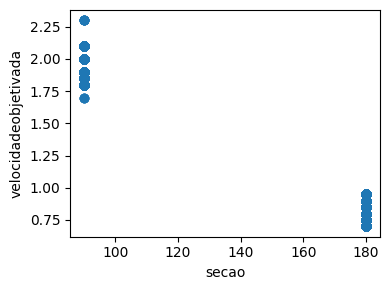

In [999]:
# secao e velocidadeobjetivada estão com uma correlação negativa muito forte, quando uma é pequena a outra é grande
# provavelmente a secao define a velocidade, secao grande menor velocidade e secao pequena maior velocidade

plt.figure(figsize=(4, 3))

plt.scatter(df['secao'], df['velocidadeobjetivada'])
plt.xlabel('secao')
plt.ylabel('velocidadeobjetivada')
plt.tight_layout()
plt.show()

In [1000]:
# Como seção e velocidadeobjetivada estão muito correlacionadas uma deve ser removida
# VIF velocidadeobjetivada > secao, velocidadeobjetivada tem maior multicolinearidade
# Correlação com a target velocidadeobjetivada < seção, velocidadeobjetivada tem menor relação com a target
# velocidadeobjetivada pode ser removida

df_corr = df_corr.drop(columns=['velocidadeobjetivada'])

In [1001]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Select the independent variables
X = df_corr[['secao', 'al_min', 'c_min', 'c_max', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 'sugestaomodelolegado', 'temperaturaobjetivada', 'acoatual_woe', 'qualidade_woe', 'panela_woe']]

# Add a constant to the independent variables dataframe
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                  feature            VIF
0                   const  165183.934640
1                   secao       1.758887
2                  al_min       2.073144
3                   c_min     188.776532
4                   c_max     184.817298
5                   n_min       1.294828
6                   s_min       1.706909
7               sequencia       1.572544
8          sequenciatotal       1.370872
9              vidapanela       1.085277
10             tempociclo       1.125945
11        tempovacuototal       3.616156
12    temperaturaliquidus       6.666989
13   sugestaomodelolegado       5.755187
14  temperaturaobjetivada      14.032297
15           acoatual_woe       1.877850
16          qualidade_woe       7.834411
17             panela_woe       1.006659


**Análise do carbono**

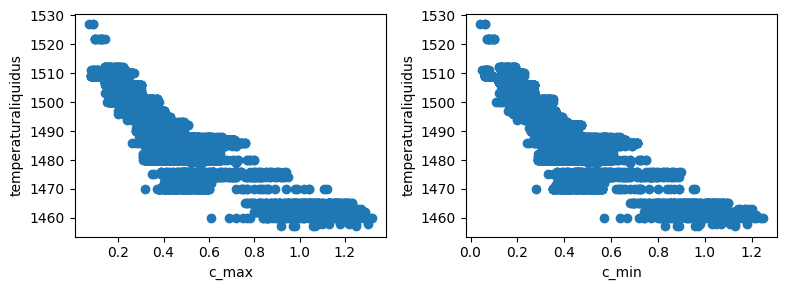

In [1002]:
# c_min e c_max estão com uma correlação positiva muito forte entre si, quando um aumenta o outro também aumenta
# além disso, ambos apresentam uma correlação negativa muito forte com a temperaturaliquidus

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].scatter(df['c_max'], df['temperaturaliquidus'])
axes[0].set_xlabel('c_max')
axes[0].set_ylabel('temperaturaliquidus')

axes[1].scatter(df['c_min'], df['temperaturaliquidus'])
axes[1].set_xlabel('c_min')
axes[1].set_ylabel('temperaturaliquidus')

plt.tight_layout()
plt.show()

O teor de carbono tem grande influênca na temperatura de fusão do aço

De acordo com o diagrama de fases do ferro-carbono, o teor de carono do aço varia entre 0 e 2

Além disso, a temperatura de fusão do aço diminui com o aumento de carbono, isso explica a forte correlação negativa com a temperaturaliquidus

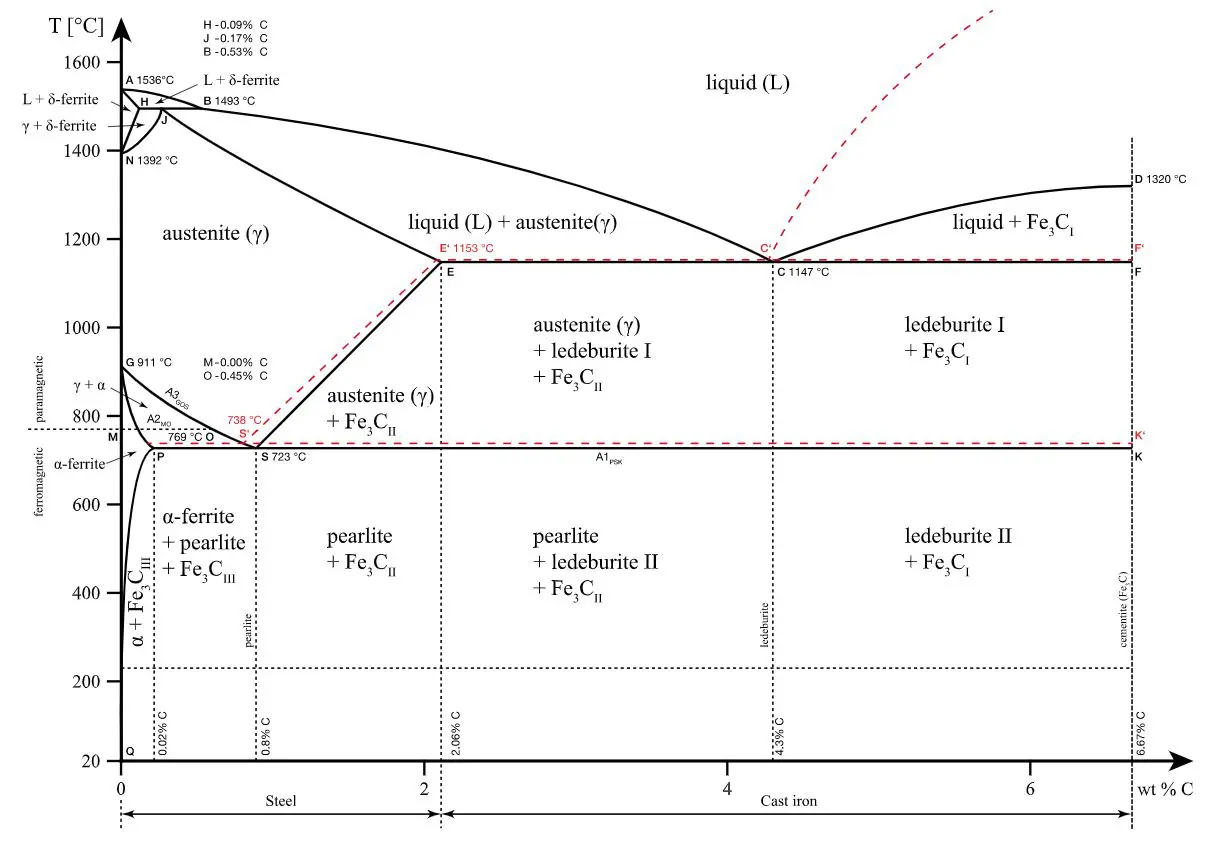

In [1003]:
# para evitar multicolinearidade as variáveis c_min e c_max foram unidas em uma única variável c_medio

df_corr["c_medio"] = df_corr[["c_min", "c_max"]].mean(axis=1)

df_corr = df_corr.drop(columns=["c_min", "c_max"])

In [1005]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Select the independent variables
X = df_corr[['secao', 'al_min', 'c_medio', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 'sugestaomodelolegado', 'temperaturaobjetivada', 'acoatual_woe', 'qualidade_woe', 'panela_woe']]

# Add a constant to the independent variables dataframe
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                  feature            VIF
0                   const  159391.398574
1                   secao       1.758200
2                  al_min       2.045496
3                 c_medio       4.907203
4                   n_min       1.288759
5                   s_min       1.695462
6               sequencia       1.568944
7          sequenciatotal       1.368256
8              vidapanela       1.085240
9              tempociclo       1.125898
10        tempovacuototal       3.602957
11    temperaturaliquidus       6.513055
12   sugestaomodelolegado       5.747292
13  temperaturaobjetivada      13.906032
14           acoatual_woe       1.877485
15          qualidade_woe       7.508565
16             panela_woe       1.006461


In [1007]:
# c_medio e temperaturaliquidus apresentam alta correlação, um deve ser removido
# como a temperaturaliquidus apresentar maior multicolinearidade
# temperaturaliquidus pode ser removida

df_corr = df_corr.drop(columns=['temperaturaliquidus'])

In [1009]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Select the independent variables
X = df_corr[['secao', 'al_min', 'c_medio', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'vidapanela', 'tempociclo', 'tempovacuototal', 'sugestaomodelolegado', 'temperaturaobjetivada', 'acoatual_woe', 'qualidade_woe', 'panela_woe']]

# Add a constant to the independent variables dataframe
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                  feature            VIF
0                   const  117669.308949
1                   secao       1.698398
2                  al_min       1.790667
3                 c_medio       3.679447
4                   n_min       1.285685
5                   s_min       1.692322
6               sequencia       1.568931
7          sequenciatotal       1.351721
8              vidapanela       1.084743
9              tempociclo       1.124170
10        tempovacuototal       3.602832
11   sugestaomodelolegado       5.747252
12  temperaturaobjetivada      12.975585
13           acoatual_woe       1.873049
14          qualidade_woe       7.487291
15             panela_woe       1.004558


**Análise temperaturaobjetivada**

In [1010]:
# temperaturaobjetivada está com uma multicolinearidade muito alta, pode ser removida

df_corr = df_corr.drop(columns=['temperaturaobjetivada'])

In [1011]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Select the independent variables
X = df_corr[['secao', 'al_min', 'c_medio', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'vidapanela', 'tempociclo', 'tempovacuototal', 'sugestaomodelolegado', 'acoatual_woe', 'qualidade_woe', 'panela_woe']]

# Add a constant to the independent variables dataframe
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                 feature           VIF
0                  const  28332.206303
1                  secao      1.628471
2                 al_min      1.675842
3                c_medio      2.713578
4                  n_min      1.229792
5                  s_min      1.690547
6              sequencia      1.506078
7         sequenciatotal      1.335967
8             vidapanela      1.081129
9             tempociclo      1.115859
10       tempovacuototal      2.788628
11  sugestaomodelolegado      4.753086
12          acoatual_woe      1.861676
13         qualidade_woe      4.445687
14            panela_woe      1.004354


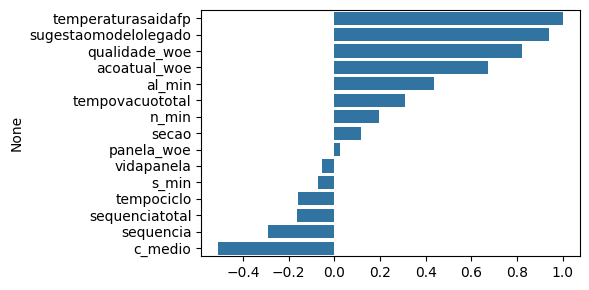

In [1014]:
plt.figure(figsize=(6,3))

correlacoes = df_corr.corr(method='spearman', numeric_only=True)['temperaturasaidafp'].sort_values(ascending=False)
sns.barplot(x=correlacoes.values, y=correlacoes.index)
plt.tight_layout()
plt.show()

# Valores próximos de 1 → correlação positiva forte
# Valores próximos de -1 → correlação negativa forte
# Valores próximos de 0 → pouca ou nenhuma correlação linear